# 00. 공식 데이터 감사

이 노트북은 DACON **제3회 풍력발전량 예측 AI 경진대회 - BARAM 2026** 공식 배포 데이터를 모델링 전에 감사하기 위한 기준 문서입니다.

분석 범위는 파일 무결성, 명세 대비 shape/기간/컬럼, LDAPS/GFS 예보 격자와 lead time, label 품질, SCADA 원천 품질, `info.xlsx` 설비 메타, `sample_submission.csv` 스키마입니다.

이번 노트북에서는 모델 학습, inference 분리, 리더보드 제출, 제출 CSV 생성, 모델 산출물 저장을 하지 않습니다.


## 목차

1. 실행 환경과 감사 경계
2. MANIFEST hash와 파일 존재 확인
3. data_description 기준 파일 inventory
4. LDAPS/GFS 예보 데이터 감사
5. train_labels와 sample_submission 감사
6. SCADA와 info.xlsx 감사
7. Decision Box


## Decision Box 0: 이번 감사의 경계

| 항목 | 결정 |
|---|---|
| 원본 데이터 | `data/raw/open/**`는 읽기 전용으로만 사용하고 Git stage 금지 |
| 분석 산출물 | 모델·제출·output 파일은 생성하지 않음 |
| 해석 단위 | 표/시각화마다 `관찰 -> 해석 -> 다음 판단`을 기록 |
| 시간 기준 | 모든 시간은 KST, 예보 feature는 `data_available_kst_dtm` 기준으로 누수 점검 |
| 평가 관점 | FICR의 10% capacity 유효 구간, NWP forecast lead, SCADA/power curve, 시계열 validation 기준을 함께 본다 |


In [1]:
from pathlib import Path
import hashlib
import json
import math
import re
import warnings

import matplotlib.font_manager as fontManager
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

projectRoot = Path.cwd().resolve()
if projectRoot.name == "notebooks":
  projectRoot = projectRoot.parent

dataRoot = projectRoot / "data" / "raw" / "open"
trainRoot = dataRoot / "train"
testRoot = dataRoot / "test"

csvPaths = {
  "ldaps_train": trainRoot / "ldaps_train.csv",
  "gfs_train": trainRoot / "gfs_train.csv",
  "train_labels": trainRoot / "train_labels.csv",
  "scada_vestas_train": trainRoot / "scada_vestas_train.csv",
  "scada_unison_train": trainRoot / "scada_unison_train.csv",
  "ldaps_test": testRoot / "ldaps_test.csv",
  "gfs_test": testRoot / "gfs_test.csv",
  "sample_submission": dataRoot / "sample_submission.csv",
}

metaPaths = {
  "data_description": dataRoot / "data_description.md",
  "info": dataRoot / "info.xlsx",
  "manifest": dataRoot / "MANIFEST.md",
}

targetColumns = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
capacityKwh = {
  "kpx_group_1": 21600.0,
  "kpx_group_2": 21600.0,
  "kpx_group_3": 21000.0,
}

availableFonts = {font.name for font in fontManager.fontManager.ttflist}
if "Malgun Gothic" in availableFonts:
  plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", font=plt.rcParams.get("font.family", ["sans-serif"])[0])

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

def readCsv(path):
  return pd.read_csv(path, encoding="utf-8-sig")

def sha256File(path):
  hashObj = hashlib.sha256()
  with path.open("rb") as fileObj:
    for block in iter(lambda: fileObj.read(1024 * 1024), b""):
      hashObj.update(block)
  return hashObj.hexdigest()

def parseManifest(path):
  text = path.read_text(encoding="utf-8")
  rows = []
  pattern = re.compile(r"\| `([^`]+)` \| ([0-9]+) \| `([0-9a-f]{64})` \|")
  for relPath, sizeText, digest in pattern.findall(text):
    rows.append({
      "상대경로": relPath,
      "기대크기_bytes": int(sizeText),
      "기대_SHA256": digest,
    })
  return pd.DataFrame(rows)

def parseDmsPair(text):
  pattern = re.compile(
    r"(\d+)°(\d+)'([\d.]+)\"([NS])\s+(\d+)°(\d+)'([\d.]+)\"([EW])"
  )
  match = pattern.search(str(text))
  if not match:
    return np.nan, np.nan
  latDeg, latMin, latSec, latHem, lonDeg, lonMin, lonSec, lonHem = match.groups()
  lat = int(latDeg) + int(latMin) / 60 + float(latSec) / 3600
  lon = int(lonDeg) + int(lonMin) / 60 + float(lonSec) / 3600
  if latHem == "S":
    lat *= -1
  if lonHem == "W":
    lon *= -1
  return lat, lon

def loadInfoTable(path):
  rawInfo = pd.read_excel(path, header=None)
  header = rawInfo.iloc[3, 1:].tolist()
  infoTable = rawInfo.iloc[4:, 1:].copy()
  infoTable.columns = header
  infoTable = infoTable.dropna(how="all").reset_index(drop=True)
  infoTable["KPX그룹"] = infoTable["KPX그룹"].ffill().astype(int)
  infoTable["그룹설비용량(MW)"] = infoTable["그룹설비용량(MW)"].ffill().astype(float)
  for numericCol in ["단계", "호기", "Hub Height(m)", "Rotor Diameter(m)", "설비용량(MW)"]:
    infoTable[numericCol] = pd.to_numeric(infoTable[numericCol])
  coords = infoTable["좌표(Google)"].apply(parseDmsPair)
  infoTable["latitude"] = [lat for lat, _ in coords]
  infoTable["longitude"] = [lon for _, lon in coords]
  return infoTable

def timeContinuity(series, freq):
  parsed = pd.to_datetime(series)
  expected = pd.date_range(parsed.min(), parsed.max(), freq=freq)
  return {
    "시작": parsed.min(),
    "종료": parsed.max(),
    "고유시각수": parsed.nunique(),
    "기대시각수": len(expected),
    "중복시각수": int(parsed.duplicated().sum()),
    "누락시각수": int(len(expected.difference(parsed.drop_duplicates().sort_values()))),
  }

print(f"프로젝트 루트: {projectRoot}")
print(f"데이터 루트: {dataRoot}")


프로젝트 루트: C:\Users\kik32\workspace\Dacon\2026-BARAM-Wind-Power-Prediction-AI-Competition
데이터 루트: C:\Users\kik32\workspace\Dacon\2026-BARAM-Wind-Power-Prediction-AI-Competition\data\raw\open


### 관찰 -> 해석 -> 다음 판단

**관찰**: 감사 코드는 프로젝트 루트와 `data/raw/open`을 기준으로 모든 공식 파일 경로를 고정한다.

**해석**: 풍력 예측 대회에서는 원본 데이터의 파일명·기간·시간대가 곧 재현성 계약이다. 특히 NWP 예보는 target 시각뿐 아니라 `data_available_kst_dtm`이 함께 있어야 forecast lead와 cutoff를 검증할 수 있다.

**다음 판단**: 이후 모든 join과 validation 후보는 이 경로·시간 기준을 통과한 데이터만 사용한다.


## 1. MANIFEST hash와 파일 존재 확인


In [2]:
manifestExpected = parseManifest(metaPaths["manifest"])
manifestRows = []

for row in manifestExpected.to_dict("records"):
  filePath = projectRoot / row["상대경로"]
  exists = filePath.exists()
  actualSize = filePath.stat().st_size if exists else np.nan
  actualHash = sha256File(filePath) if exists else ""
  manifestRows.append({
    "상대경로": row["상대경로"],
    "존재": exists,
    "크기일치": bool(exists and actualSize == row["기대크기_bytes"]),
    "해시일치": bool(exists and actualHash == row["기대_SHA256"]),
    "기대크기_bytes": row["기대크기_bytes"],
    "실제크기_bytes": actualSize,
    "SHA256_앞12자리": actualHash[:12] if exists else "",
  })

manifestAudit = pd.DataFrame(manifestRows)
display(manifestAudit)
print("MANIFEST 전체 통과:", bool(manifestAudit[["존재", "크기일치", "해시일치"]].all().all()))


,상대경로,존재,크기일치,해시일치,기대크기_bytes,실제크기_bytes,SHA256_앞12자리
0,data/raw/open/data_description.md,True,True,True,11694,11694,515ba62cba29
1,data/raw/open/info.xlsx,True,True,True,3823422,3823422,89e83a52e0eb
2,data/raw/open/sample_submission.csv,True,True,True,359229,359229,c925d2066a83
3,data/raw/open/test/gfs_test.csv,True,True,True,28037722,28037722,aa33febb24ec
4,data/raw/open/test/ldaps_test.csv,True,True,True,43122637,43122637,60e94f7cc803
5,data/raw/open/train/gfs_train.csv,True,True,True,84315594,84315594,cd56b67d357e
6,data/raw/open/train/ldaps_train.csv,True,True,True,129687357,129687357,61ae944e7ae1
7,data/raw/open/train/scada_unison_train.csv,True,True,True,16788646,16788646,5d8ccd7ac6b1
8,data/raw/open/train/scada_vestas_train.csv,True,True,True,33458140,33458140,f024f3ca57bb
9,data/raw/open/train/train_labels.csv,True,True,True,1138967,1138967,47bb64252195


MANIFEST 전체 통과: True


### 관찰 -> 해석 -> 다음 판단

**관찰**: MANIFEST는 공식 원본 미러의 파일 존재, byte size, SHA256을 동시에 검증한다.

**해석**: 데이터 품질 감사에서 hash 검증은 EDA보다 앞선다. 같은 파일명이라도 참가자 로컬에서 Excel 재저장, 부분 다운로드, 압축 해제 오류가 섞이면 label/forecast 기간 해석 이전에 재현성이 깨진다.

**다음 판단**: 노트북과 모델링 코드는 원본 CSV/XLSX를 수정하지 않는다. 원본이 바뀌면 MANIFEST 갱신 PR을 별도 작업으로 분리한다.


## 2. data_description 기준 파일 inventory


In [3]:
expectedSpec = pd.DataFrame([
  {"키": "ldaps_train", "파일": "train/ldaps_train.csv", "명세행수": 420864, "시각컬럼": "forecast_kst_dtm", "기대시작": "2022-01-01 01:00:00", "기대종료": "2025-01-01 00:00:00"},
  {"키": "gfs_train", "파일": "train/gfs_train.csv", "명세행수": 236736, "시각컬럼": "forecast_kst_dtm", "기대시작": "2022-01-01 01:00:00", "기대종료": "2025-01-01 00:00:00"},
  {"키": "train_labels", "파일": "train/train_labels.csv", "명세행수": 26304, "시각컬럼": "kst_dtm", "기대시작": "2022-01-01 01:00:00", "기대종료": "2025-01-01 00:00:00"},
  {"키": "scada_vestas_train", "파일": "train/scada_vestas_train.csv", "명세행수": 157819, "시각컬럼": "kst_dtm", "기대시작": "2022-01-01 01:00:00", "기대종료": "2025-01-01 00:00:00"},
  {"키": "scada_unison_train", "파일": "train/scada_unison_train.csv", "명세행수": 105264, "시각컬럼": "kst_dtm", "기대시작": "2023-01-01 00:10:00", "기대종료": "2025-01-01 00:00:00"},
  {"키": "ldaps_test", "파일": "test/ldaps_test.csv", "명세행수": 140160, "시각컬럼": "forecast_kst_dtm", "기대시작": "2025-01-01 01:00:00", "기대종료": "2026-01-01 00:00:00"},
  {"키": "gfs_test", "파일": "test/gfs_test.csv", "명세행수": 78840, "시각컬럼": "forecast_kst_dtm", "기대시작": "2025-01-01 01:00:00", "기대종료": "2026-01-01 00:00:00"},
  {"키": "sample_submission", "파일": "sample_submission.csv", "명세행수": 8760, "시각컬럼": "forecast_kst_dtm", "기대시작": "2025-01-01 01:00:00", "기대종료": "2026-01-01 00:00:00"},
])

csvFrames = {key: readCsv(path) for key, path in csvPaths.items()}
inventoryRows = []

for row in expectedSpec.to_dict("records"):
  frame = csvFrames[row["키"]]
  timeValues = pd.to_datetime(frame[row["시각컬럼"]])
  inventoryRows.append({
    "파일": row["파일"],
    "행수": len(frame),
    "명세행수": row["명세행수"],
    "행수일치": len(frame) == row["명세행수"],
    "컬럼수": frame.shape[1],
    "시작": timeValues.min(),
    "종료": timeValues.max(),
    "기간일치": str(timeValues.min()) == row["기대시작"] and str(timeValues.max()) == row["기대종료"],
    "고유시각수": timeValues.nunique(),
    "결측셀수": int(frame.isna().sum().sum()),
  })

inventoryAudit = pd.DataFrame(inventoryRows)
display(inventoryAudit)


,파일,행수,명세행수,행수일치,컬럼수,시작,종료,기간일치,고유시각수,결측셀수
0,train/ldaps_train.csv,420864,420864,True,35,2022-01-01 01:00:00,2025-01-01,True,26304,0
1,train/gfs_train.csv,236736,236736,True,40,2022-01-01 01:00:00,2025-01-01,True,26304,0
2,train/train_labels.csv,26304,26304,True,4,2022-01-01 01:00:00,2025-01-01,True,26304,8973
3,train/scada_vestas_train.csv,157819,157819,True,37,2022-01-01 01:00:00,2025-01-01,True,157819,0
4,train/scada_unison_train.csv,105264,105264,True,16,2023-01-01 00:10:00,2025-01-01,True,105264,9511
5,test/ldaps_test.csv,140160,140160,True,35,2025-01-01 01:00:00,2026-01-01,True,8760,752
6,test/gfs_test.csv,78840,78840,True,40,2025-01-01 01:00:00,2026-01-01,True,8760,0
7,sample_submission.csv,8760,8760,True,5,2025-01-01 01:00:00,2026-01-01,True,8760,0


### 관찰 -> 해석 -> 다음 판단

**관찰**: 공식 CSV 파일의 행 수와 기간은 명세와 맞고, SCADA UNISON은 2023년부터 시작한다.

**해석**: train label과 NWP는 같은 hourly target 축을 공유하지만, SCADA는 10분 실측이며 제조사별 제공 기간도 다르다. 따라서 모든 데이터를 하나의 rectangular table로 즉시 합치기보다 source별 clock과 availability를 먼저 존중해야 한다.

**다음 판단**: 모델링 단계에서는 NWP와 label을 주 학습축으로 두고, SCADA는 별도 EDA와 물리적 feature sanity check에 먼저 사용한다.


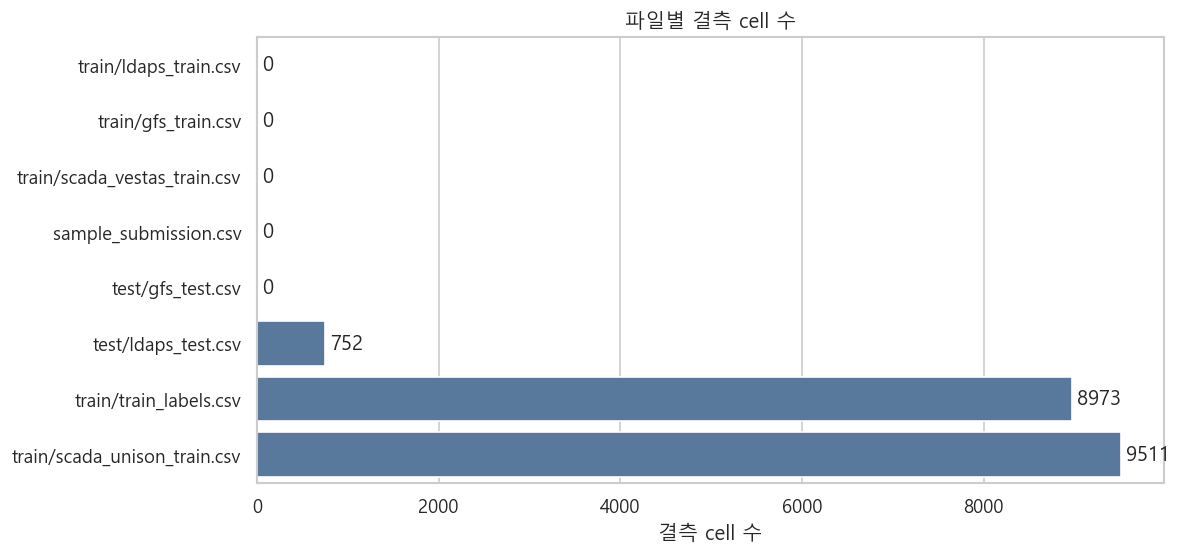

In [4]:
missingByFile = inventoryAudit.sort_values("결측셀수", ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=missingByFile, y="파일", x="결측셀수", ax=ax, color="#4C78A8")
ax.set_title("파일별 결측 cell 수")
ax.set_xlabel("결측 cell 수")
ax.set_ylabel("")
for container in ax.containers:
  ax.bar_label(container, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: 결측은 주로 `train_labels`, `scada_unison_train`, `ldaps_test`에 집중된다.

**해석**: 세 결측은 성격이 다르다. Group 3 label 결측은 제공 기간의 구조적 공백, UNISON 결측은 SCADA 수집 품질 문제, LDAPS test 결측은 평가 기간 예보 feature 결측이다. 같은 `fillna`로 처리하면 데이터 생성 원인을 지우게 된다.

**다음 판단**: 결측 처리 정책은 source별로 분리한다. label은 학습 mask, SCADA는 품질 감사/EDA, weather는 제출 재현 가능한 imputation 후보로 다룬다.


## 3. LDAPS/GFS 예보 데이터 감사


In [5]:
weatherKeys = ["ldaps_train", "ldaps_test", "gfs_train", "gfs_test"]
weatherRows = []

for key in weatherKeys:
  frame = csvFrames[key]
  forecastTime = pd.to_datetime(frame["forecast_kst_dtm"])
  availableTime = pd.to_datetime(frame["data_available_kst_dtm"])
  leadHours = (forecastTime - availableTime).dt.total_seconds() / 3600
  gridCoverage = frame.groupby("forecast_kst_dtm")["grid_id"].nunique()
  weatherRows.append({
    "데이터": key,
    "행수": len(frame),
    "컬럼수": frame.shape[1],
    "예보시각수": forecastTime.nunique(),
    "격자수": frame["grid_id"].nunique(),
    "격자coverage_min": int(gridCoverage.min()),
    "격자coverage_max": int(gridCoverage.max()),
    "lead_min_h": leadHours.min(),
    "lead_max_h": leadHours.max(),
    "lead_unique": leadHours.nunique(),
    "available_고유시각수": availableTime.nunique(),
    "결측셀수": int(frame.isna().sum().sum()),
  })

weatherAudit = pd.DataFrame(weatherRows)
display(weatherAudit)


,데이터,행수,컬럼수,예보시각수,격자수,격자coverage_min,격자coverage_max,lead_min_h,lead_max_h,lead_unique,available_고유시각수,결측셀수
0,ldaps_train,420864,35,26304,16,16,16,12.0,35.0,24,1096,0
1,ldaps_test,140160,35,8760,16,16,16,12.0,35.0,24,365,752
2,gfs_train,236736,40,26304,9,9,9,12.0,35.0,24,1096,0
3,gfs_test,78840,40,8760,9,9,9,12.0,35.0,24,365,0


### 관찰 -> 해석 -> 다음 판단

**관찰**: LDAPS는 forecast 시각마다 16개 grid, GFS는 9개 grid가 유지되고 lead는 12~35시간의 24개 값으로 반복된다.

**해석**: BARAM 공식 데이터는 매일 09시 초기화 예보 중 다음날 01시부터 다음날 00시까지를 13시부터 사용 가능하다고 보는 구조다. 풍력 예측에서 lead가 길어질수록 풍속·풍향 오차가 커질 수 있으므로, lead hour는 단순 calendar feature가 아니라 예보 신뢰도 feature다.

**다음 판단**: baseline의 격자 평균을 출발점으로 쓰되, 이후 모델에서는 `lead_hour`, `data_available_kst_dtm`, target hour, LDAPS/GFS source를 명시 feature로 관리한다.


,source,split,격자수,위도_min,위도_max,경도_min,경도_max
0,GFS,test,9,37.0000,37.5000,128.7500,129.2500
1,GFS,train,9,37.0000,37.5000,128.7500,129.2500
2,LDAPS,test,16,37.2607,37.3032,128.9257,128.9958
3,LDAPS,train,16,37.2607,37.3032,128.9257,128.9958


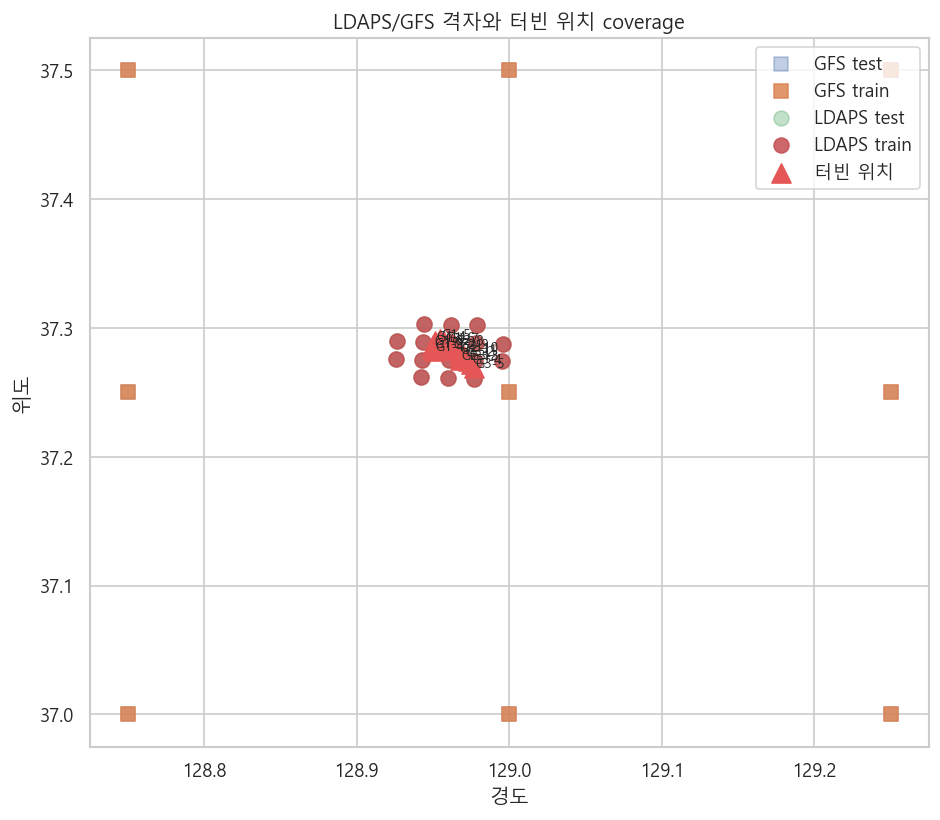

In [6]:
infoTable = loadInfoTable(metaPaths["info"])

gridRows = []
for key in weatherKeys:
  sourceName = "LDAPS" if "ldaps" in key else "GFS"
  splitName = "train" if key.endswith("train") else "test"
  coords = csvFrames[key][["grid_id", "latitude", "longitude"]].drop_duplicates().copy()
  coords["source"] = sourceName
  coords["split"] = splitName
  gridRows.append(coords)

gridCoords = pd.concat(gridRows, ignore_index=True).drop_duplicates(["source", "split", "grid_id"])
display(gridCoords.groupby(["source", "split"]).agg(
  격자수=("grid_id", "nunique"),
  위도_min=("latitude", "min"),
  위도_max=("latitude", "max"),
  경도_min=("longitude", "min"),
  경도_max=("longitude", "max"),
).reset_index())

fig, ax = plt.subplots(figsize=(8, 7))
for (sourceName, splitName), group in gridCoords.groupby(["source", "split"]):
  marker = "o" if sourceName == "LDAPS" else "s"
  alpha = 0.85 if splitName == "train" else 0.35
  ax.scatter(group["longitude"], group["latitude"], s=80, marker=marker, alpha=alpha, label=f"{sourceName} {splitName}")

ax.scatter(infoTable["longitude"], infoTable["latitude"], s=130, c="#E45756", marker="^", label="터빈 위치")
for _, row in infoTable.iterrows():
  ax.text(row["longitude"] + 0.001, row["latitude"] + 0.001, f"G{row['KPX그룹']}-{int(row['호기'])}", fontsize=8)

ax.set_title("LDAPS/GFS 격자와 터빈 위치 coverage")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: LDAPS 격자는 터빈 군집을 촘촘히 감싸고, GFS 격자는 더 넓은 범위를 성긴 해상도로 덮는다.

**해석**: 풍력 발전량은 터빈 높이의 국지 풍황과 지형 영향에 민감하다. LDAPS는 국지 wind regime 포착에 유리하고, GFS는 synoptic-scale 변화와 lead 안정성 보완 신호로 보는 것이 실무적으로 자연스럽다.

**다음 판단**: 첫 feature set은 source별 평균·분산을 분리하고, 이후 터빈 좌표와 grid 거리 기반 가중 평균을 후보로 올린다.


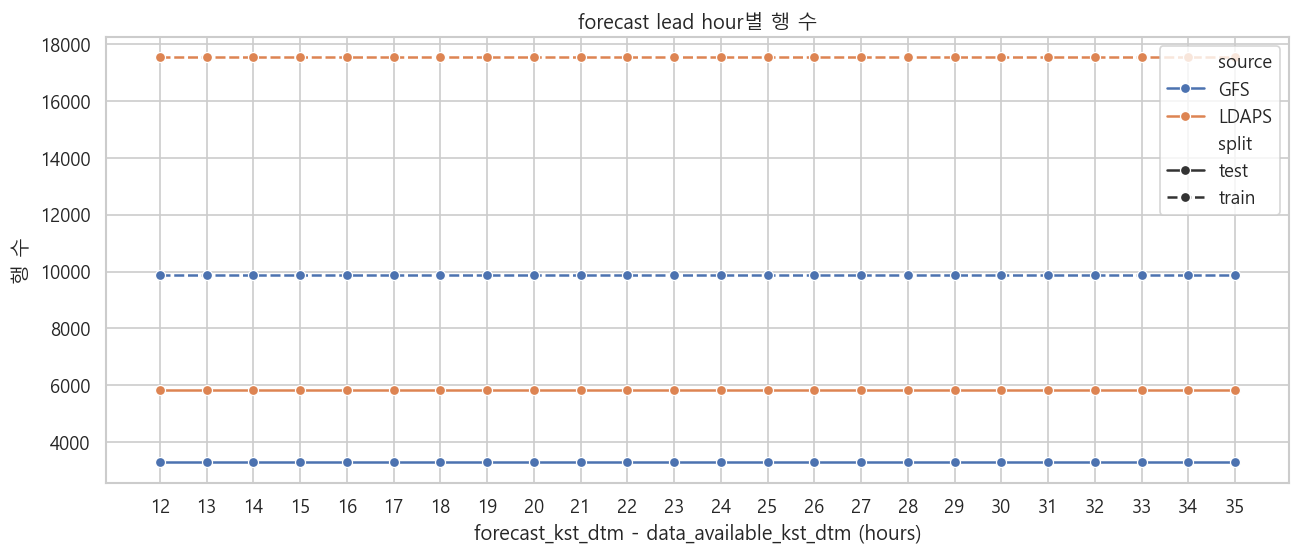

In [7]:
leadRows = []
for key in weatherKeys:
  frame = csvFrames[key]
  forecastTime = pd.to_datetime(frame["forecast_kst_dtm"])
  availableTime = pd.to_datetime(frame["data_available_kst_dtm"])
  sourceName = "LDAPS" if "ldaps" in key else "GFS"
  splitName = "train" if key.endswith("train") else "test"
  leadFrame = pd.DataFrame({
    "source": sourceName,
    "split": splitName,
    "lead_hour": ((forecastTime - availableTime).dt.total_seconds() / 3600).astype(int),
  })
  leadRows.append(leadFrame)

leadAudit = pd.concat(leadRows, ignore_index=True)
leadCounts = leadAudit.groupby(["source", "split", "lead_hour"]).size().reset_index(name="row_count")

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.lineplot(data=leadCounts, x="lead_hour", y="row_count", hue="source", style="split", marker="o", ax=ax)
ax.set_title("forecast lead hour별 행 수")
ax.set_xlabel("forecast_kst_dtm - data_available_kst_dtm (hours)")
ax.set_ylabel("행 수")
ax.set_xticks(range(12, 36))
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: lead hour는 12~35시간으로 균등하게 반복되며, 모든 source/split에서 같은 패턴이다.

**해석**: 시계열 validation에서 단순히 시간 순서만 맞추면 충분하지 않다. lead별 오차 편향이 있으면 특정 시간대나 특정 예보 생성일에 FICR가 무너질 수 있다.

**다음 판단**: validation 리포트에는 전체 점수뿐 아니라 lead hour별 NMAE와 FICR를 분해하는 표를 추가한다.


,forecast_kst_dtm,결측셀수,영향grid수
0,2025-04-08 17:00:00,224,16
1,2025-06-18 18:00:00,224,16
2,2025-07-18 06:00:00,304,16


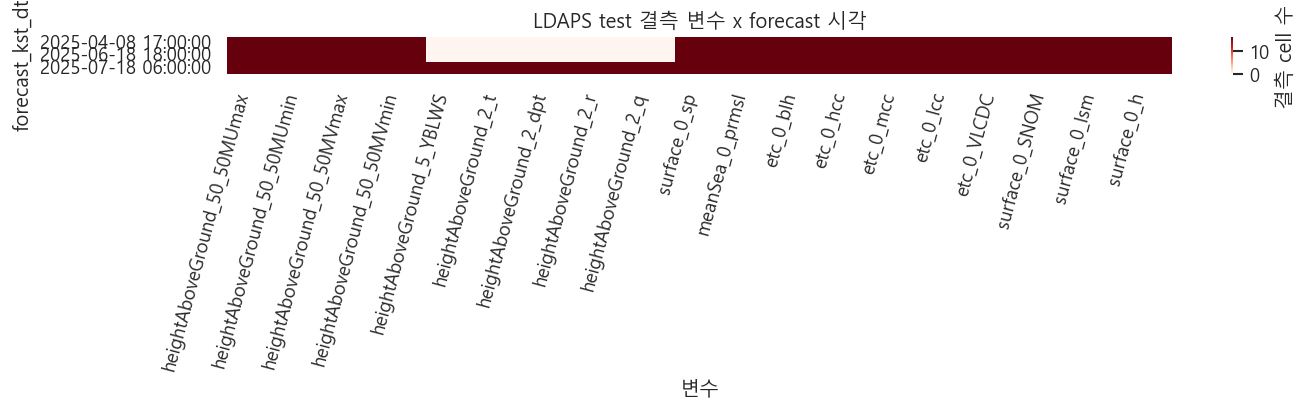

In [8]:
ldapsTest = csvFrames["ldaps_test"]
valueColumns = [col for col in ldapsTest.columns if col not in ["forecast_kst_dtm", "data_available_kst_dtm", "grid_id", "latitude", "longitude"]]
missingRows = ldapsTest[ldapsTest[valueColumns].isna().any(axis=1)].copy()

missingByForecast = (
  missingRows
  .groupby("forecast_kst_dtm")[valueColumns]
  .apply(lambda dataFrame: int(dataFrame.isna().sum().sum()))
  .reset_index(name="결측셀수")
)
missingByForecast["영향grid수"] = missingRows.groupby("forecast_kst_dtm")["grid_id"].nunique().values
display(missingByForecast)

missingMatrix = (
  ldapsTest.groupby("forecast_kst_dtm")[valueColumns]
  .apply(lambda dataFrame: dataFrame.isna().sum())
)
missingMatrix = missingMatrix.loc[(missingMatrix.sum(axis=1) > 0), (missingMatrix.sum(axis=0) > 0)]

fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(missingMatrix, cmap="Reds", cbar_kws={"label": "결측 cell 수"}, ax=ax)
ax.set_title("LDAPS test 결측 변수 x forecast 시각")
ax.set_xlabel("변수")
ax.set_ylabel("forecast_kst_dtm")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: LDAPS test 결측은 세 forecast 시각에만 나타나며, 해당 시각의 16개 grid 전체가 영향을 받는다.

**해석**: 이는 개별 grid 센서 누락보다 특정 forecast 시각의 변수군 누락에 가깝다. 평가 기간 feature 결측이므로 label 기반 보정은 불가능하고, 제출 재현 가능한 규칙으로만 처리해야 한다.

**다음 판단**: weather imputation 후보는 train 통계 기반 median, 같은 lead/hour의 source별 median, GFS 대체 feature를 비교하되, test 시각을 수작업으로 하드코딩하지 않는다.


## 4. train_labels와 sample_submission 감사


In [9]:
labels = csvFrames["train_labels"].copy()
labels["kst_dtm"] = pd.to_datetime(labels["kst_dtm"])

labelRows = []
for targetCol in targetColumns:
  series = labels[targetCol]
  cap = capacityKwh[targetCol]
  validMask = series.notna() & (series >= 0.1 * cap)
  labelRows.append({
    "target": targetCol,
    "capacity_kwh": cap,
    "missing": int(series.isna().sum()),
    "missing_pct": series.isna().mean(),
    "min": series.min(),
    "max": series.max(),
    "negative_count": int((series < 0).sum()),
    "over_capacity_count": int((series > cap).sum()),
    "valid_10pct_count": int(validMask.sum()),
    "non_null_start": labels.loc[series.notna(), "kst_dtm"].min(),
    "non_null_end": labels.loc[series.notna(), "kst_dtm"].max(),
  })

labelAudit = pd.DataFrame(labelRows)
display(labelAudit)

labelTimeAudit = pd.DataFrame([timeContinuity(labels["kst_dtm"], "h")])
display(labelTimeAudit)


,target,capacity_kwh,missing,missing_pct,min,max,negative_count,over_capacity_count,valid_10pct_count,non_null_start,non_null_end
0,kpx_group_1,21600.0,104,0.003954,0.0,21275.305,0,0,15915,2022-01-01 01:00:00,2025-01-01
1,kpx_group_2,21600.0,103,0.003916,0.0,21362.084,0,0,15891,2022-01-01 01:00:00,2025-01-01
2,kpx_group_3,21000.0,8766,0.333257,0.0,21130.674,0,38,9414,2023-01-01 01:00:00,2025-01-01


,시작,종료,고유시각수,기대시각수,중복시각수,누락시각수
0,2022-01-01 01:00:00,2025-01-01,26304,26304,0,0


### 관찰 -> 해석 -> 다음 판단

**관찰**: Group 1/2는 소량 결측만 있고 capacity 초과가 없지만, Group 3은 2022년 구조적 결측과 소량 capacity 초과가 있다.

**해석**: 공식 metric은 capacity 10% 이상인 actual을 유효 구간으로 보며, FICR도 capacity 기반 오차 허용폭을 사용한다. Group 3의 2022년 공백을 단순 0으로 채우면 풍력 정지 상태와 미제공 상태를 혼동하게 되고, capacity 초과 actual은 SCADA/정산 집계 경계의 원천 품질 이슈로 별도 기록해야 한다.

**다음 판단**: 학습 mask는 target별로 분리한다. Group 3은 2023년 이후 중심으로 학습하고, capacity clip은 원본 label 수정이 아니라 prediction 후처리 후보로 validation에서만 비교한다.


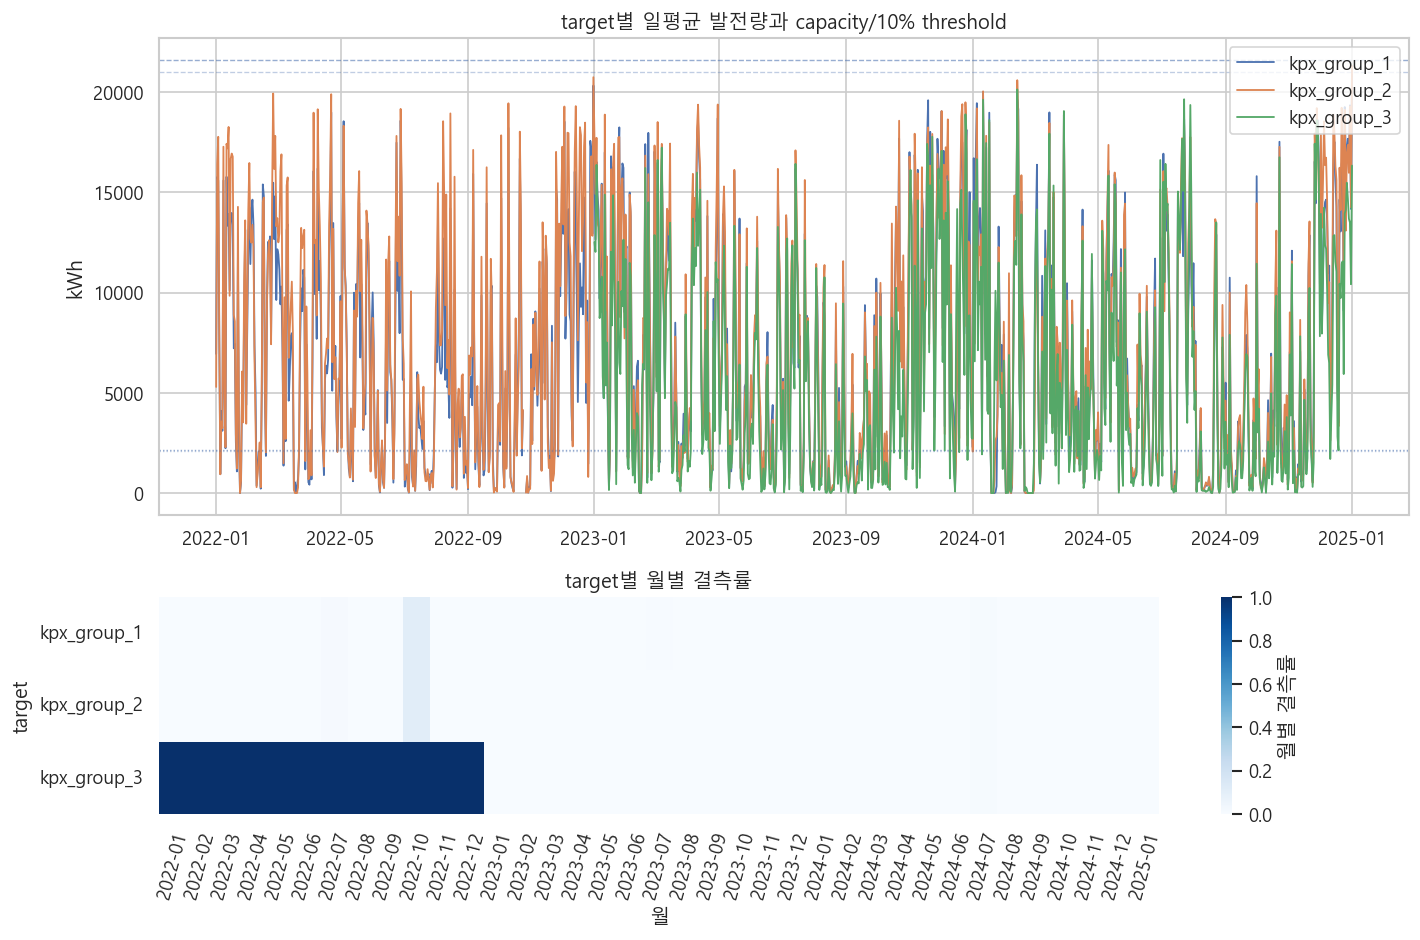

In [10]:
labelPlot = labels.set_index("kst_dtm")[targetColumns]
dailyMean = labelPlot.resample("D").mean()
monthlyMissing = labelPlot.isna().resample("MS").mean().T

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2.2, 1]})
for targetCol in targetColumns:
  axes[0].plot(dailyMean.index, dailyMean[targetCol], label=targetCol, linewidth=1.1)
  axes[0].axhline(capacityKwh[targetCol], linestyle="--", linewidth=0.8, alpha=0.35)
  axes[0].axhline(capacityKwh[targetCol] * 0.1, linestyle=":", linewidth=0.8, alpha=0.35)
axes[0].set_title("target별 일평균 발전량과 capacity/10% threshold")
axes[0].set_ylabel("kWh")
axes[0].legend(loc="upper right")

sns.heatmap(monthlyMissing, cmap="Blues", cbar_kws={"label": "월별 결측률"}, ax=axes[1])
axes[1].set_title("target별 월별 결측률")
axes[1].set_xlabel("월")
axes[1].set_ylabel("target")
axes[1].set_xticklabels([pd.to_datetime(label.get_text()).strftime("%Y-%m") for label in axes[1].get_xticklabels()], rotation=75)

plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: Group 3의 결측은 2022년에 구조적으로 몰려 있고, 이후 기간의 시계열은 다른 그룹과 같은 hourly 축을 공유한다.

**해석**: 풍력 power curve 관점에서는 같은 풍속이라도 터빈 모델, 로터 직경, wake, 가동 제한에 따라 그룹별 출력 곡선이 다르다. Group 3을 Group 1/2와 같은 전체 기간 multi-output 문제로 다루면 미제공 구간이 모델 손실에 섞인다.

**다음 판단**: temporal validation은 마지막 10% 또는 2024 holdout을 후보로 하되, target별 non-null mask와 Group 3 capacity 초과 행을 리포트에 함께 노출한다.


,행수,컬럼,forecast_id_고유,forecast_id_결측,시작,종료,target_결측셀수,target_합계
0,8760,"forecast_id, forecast_kst_dtm, kpx_group_1, kp...",True,0,2025-01-01 01:00:00,2026-01-01,0,0.0


,시작,종료,고유시각수,기대시각수,중복시각수,누락시각수
0,2025-01-01 01:00:00,2026-01-01,8760,8760,0,0


C:\Users\kik32\AppData\Local\Temp\ipykernel_53360\3632560387.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([date.strftime("%Y-%m") for date in monthlySubmission["forecast_kst_dtm"]], rotation=70)


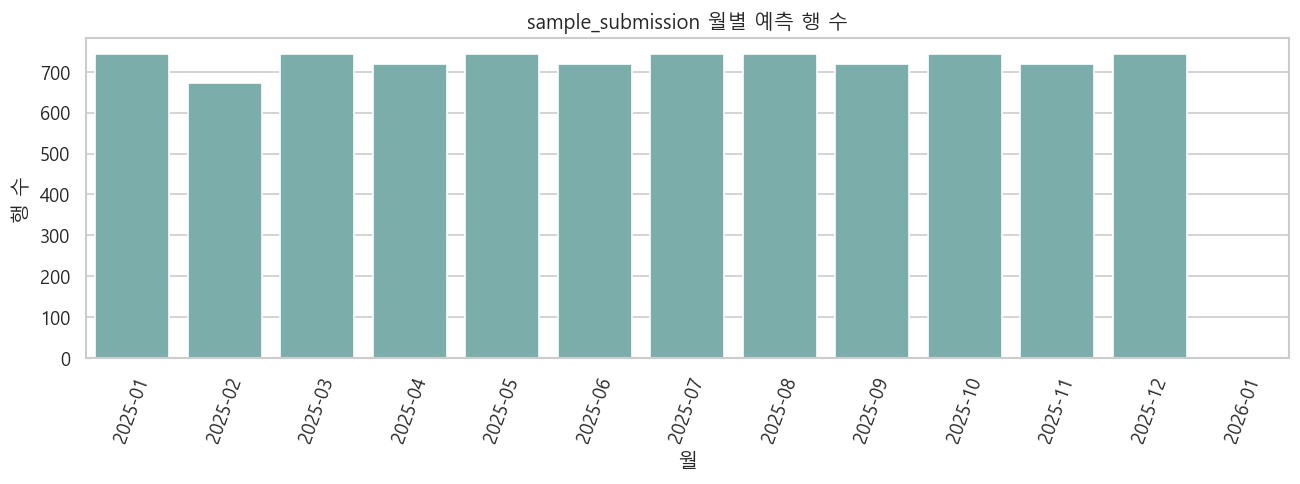

In [11]:
submission = csvFrames["sample_submission"].copy()
submission["forecast_kst_dtm"] = pd.to_datetime(submission["forecast_kst_dtm"])

submissionAudit = pd.DataFrame([{
  "행수": len(submission),
  "컬럼": ", ".join(submission.columns),
  "forecast_id_고유": bool(submission["forecast_id"].is_unique),
  "forecast_id_결측": int(submission["forecast_id"].isna().sum()),
  "시작": submission["forecast_kst_dtm"].min(),
  "종료": submission["forecast_kst_dtm"].max(),
  "target_결측셀수": int(submission[targetColumns].isna().sum().sum()),
  "target_합계": float(submission[targetColumns].sum().sum()),
}])
display(submissionAudit)
display(pd.DataFrame([timeContinuity(submission["forecast_kst_dtm"], "h")]))

monthlySubmission = submission.set_index("forecast_kst_dtm").resample("MS").size().reset_index(name="row_count")
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.barplot(data=monthlySubmission, x="forecast_kst_dtm", y="row_count", ax=ax, color="#72B7B2")
ax.set_title("sample_submission 월별 예측 행 수")
ax.set_xlabel("월")
ax.set_ylabel("행 수")
ax.set_xticklabels([date.strftime("%Y-%m") for date in monthlySubmission["forecast_kst_dtm"]], rotation=70)
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: 제출 양식은 2025년 8,760시간을 완전하게 담고 있으며 target 값은 placeholder 0이다.

**해석**: 전력시장 정산 관점에서 제출 파일은 예측값뿐 아니라 row identity가 중요하다. `forecast_id`나 시간축을 건드리면 예측 품질과 무관하게 제출 매칭 리스크가 발생한다.

**다음 판단**: 제출 생성 함수는 `sample_submission`을 template로 읽고 target 3개 컬럼만 대체한다. 공식 sample 파일 자체는 덮어쓰지 않는다.


## 5. SCADA와 info.xlsx 감사


In [12]:
scadaKeys = ["scada_vestas_train", "scada_unison_train"]
scadaRows = []

for key in scadaKeys:
  frame = csvFrames[key].copy()
  frame["kst_dtm"] = pd.to_datetime(frame["kst_dtm"])
  powerCols = [col for col in frame.columns if "power" in col]
  wsCols = [col for col in frame.columns if col.endswith("_ws")]
  wdCols = [col for col in frame.columns if col.endswith("_wd")]
  diffCounts = frame["kst_dtm"].sort_values().diff().dropna().value_counts()
  for valueName, cols in [("power", powerCols), ("ws", wsCols), ("wd", wdCols)]:
    values = frame[cols].to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]
    scadaRows.append({
      "파일": key,
      "값종류": valueName,
      "행수": len(frame),
      "컬럼수": len(cols),
      "시작": frame["kst_dtm"].min(),
      "종료": frame["kst_dtm"].max(),
      "주요간격": str(diffCounts.index[0]) if len(diffCounts) else "",
      "결측셀수": int(frame[cols].isna().sum().sum()),
      "min": float(values.min()) if len(values) else np.nan,
      "p01": float(np.quantile(values, 0.01)) if len(values) else np.nan,
      "median": float(np.quantile(values, 0.50)) if len(values) else np.nan,
      "p99": float(np.quantile(values, 0.99)) if len(values) else np.nan,
      "max": float(values.max()) if len(values) else np.nan,
      "negative_count": int((frame[cols] < 0).sum().sum()),
    })

scadaAudit = pd.DataFrame(scadaRows)
display(scadaAudit)


,파일,값종류,행수,컬럼수,시작,종료,주요간격,결측셀수,min,p01,median,p99,max,negative_count
0,scada_vestas_train,power,157819,12,2022-01-01 01:00:00,2025-01-01,0 days 00:10:00,0,-5.177042e+07,-5.000000,95.000000,601.000000,5.177042e+07,317221
1,scada_vestas_train,ws,157819,12,2022-01-01 01:00:00,2025-01-01,0 days 00:10:00,0,0.000000e+00,0.000000,6.250000,17.719000,3.111700e+01,0
2,scada_vestas_train,wd,157819,12,2022-01-01 01:00:00,2025-01-01,0 days 00:10:00,0,0.000000e+00,0.000000,252.599000,342.572000,3.590000e+02,0
3,scada_unison_train,power,105264,5,2023-01-01 00:10:00,2025-01-01,0 days 00:10:00,2214,0.000000e+00,0.000000,87.000000,702.000000,1.000000e+03,0
4,scada_unison_train,ws,105264,5,2023-01-01 00:10:00,2025-01-01,0 days 00:10:00,5096,0.000000e+00,0.780000,4.900000,16.780000,3.205000e+01,0
5,scada_unison_train,wd,105264,5,2023-01-01 00:10:00,2025-01-01,0 days 00:10:00,2201,-1.799993e+02,-171.729417,-83.585253,171.627054,1.799968e+02,362555


### 관찰 -> 해석 -> 다음 판단

**관찰**: SCADA 시간축은 10분 간격으로 연속이지만, VESTAS power에는 큰 음/양 극단값과 음수 코드가 있고 UNISON에는 결측이 있다.

**해석**: SCADA는 터빈 power curve와 풍속/풍향 convention을 확인하는 데 유용하지만, 평가 기간에는 제공되지 않는다. 따라서 raw lag feature로 쓰면 실제 제출 시 사용할 수 없는 정보를 학습하는 leakage가 된다.

**다음 판단**: SCADA는 학습 보조/EDA 전용으로 두고, 품질 규칙은 `-5`, 음수, 극단 power, 제조사별 풍향 범위를 분리해 문서화한다.


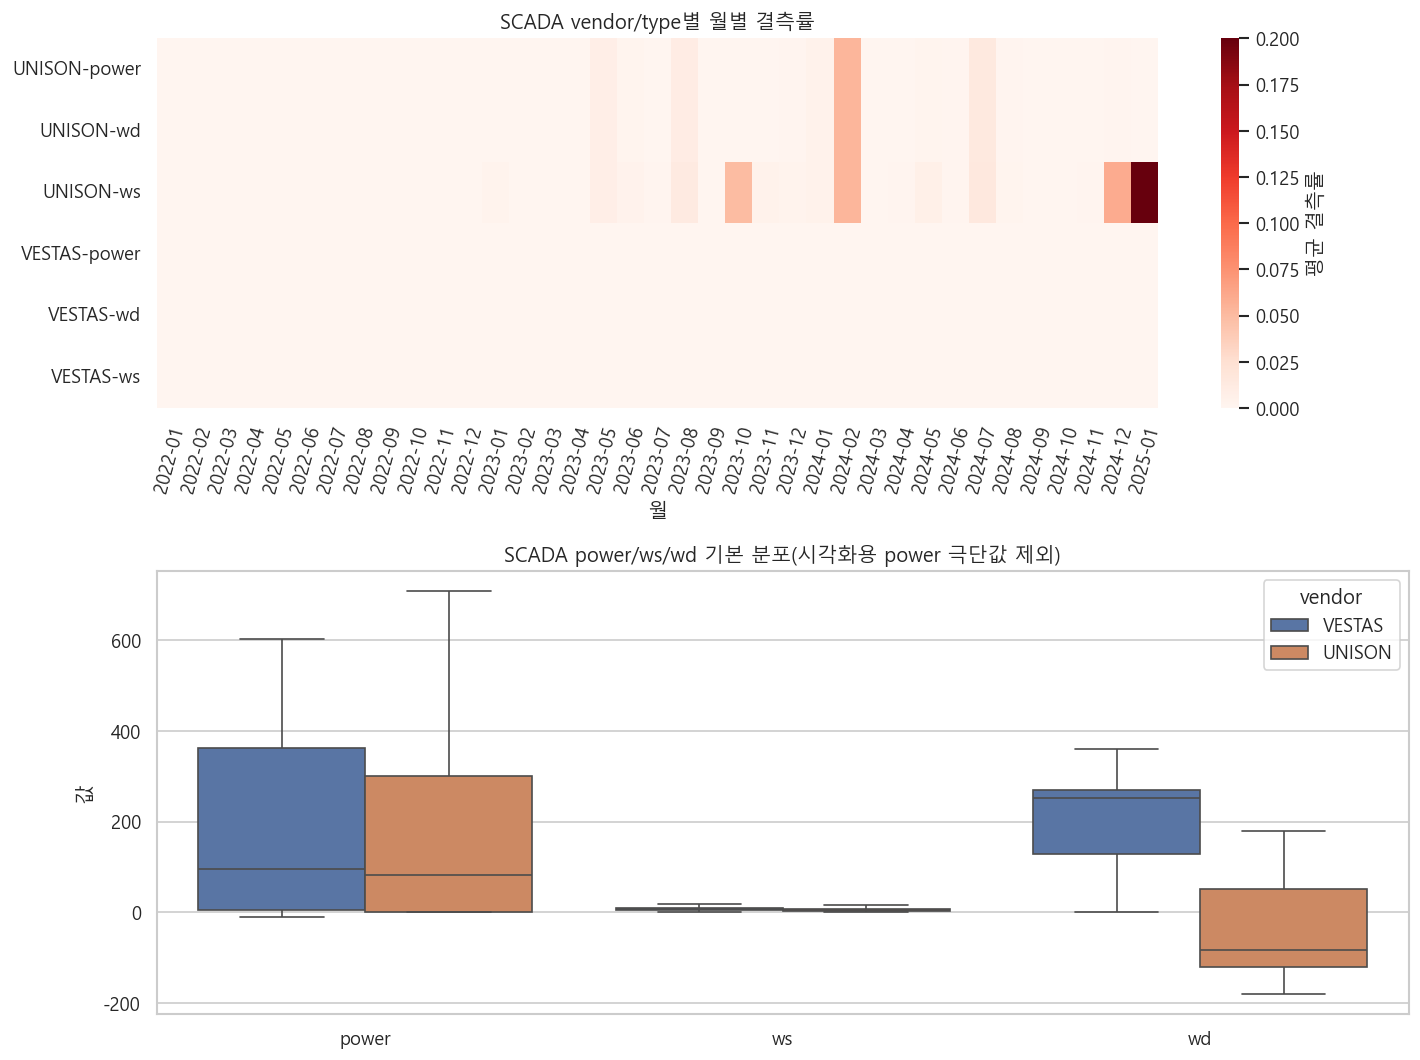

In [13]:
missingMonthRows = []
distributionRows = []

for key in scadaKeys:
  frame = csvFrames[key].copy()
  frame["kst_dtm"] = pd.to_datetime(frame["kst_dtm"])
  frame["month"] = frame["kst_dtm"].dt.to_period("M").astype(str)
  vendor = "VESTAS" if "vestas" in key else "UNISON"
  for valueName, selector in [
    ("power", lambda col: "power" in col),
    ("ws", lambda col: col.endswith("_ws")),
    ("wd", lambda col: col.endswith("_wd")),
  ]:
    cols = [col for col in frame.columns if selector(col)]
    monthMissing = frame.groupby("month")[cols].apply(lambda dataFrame: dataFrame.isna().mean().mean())
    for month, missingRate in monthMissing.items():
      missingMonthRows.append({"vendor": vendor, "값종류": valueName, "month": month, "missing_rate": missingRate})
    sampled = pd.Series(frame[cols].to_numpy(dtype=float).ravel()).dropna()
    if len(sampled) > 20000:
      sampled = sampled.sample(20000, random_state=42)
    for value in sampled:
      distributionRows.append({"vendor": vendor, "값종류": valueName, "value": value})

missingMonthAudit = pd.DataFrame(missingMonthRows)
distributionAudit = pd.DataFrame(distributionRows)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [1, 1.2]})
heatmapData = missingMonthAudit.pivot_table(index=["vendor", "값종류"], columns="month", values="missing_rate", fill_value=0)
sns.heatmap(heatmapData, cmap="Reds", cbar_kws={"label": "평균 결측률"}, ax=axes[0])
axes[0].set_title("SCADA vendor/type별 월별 결측률")
axes[0].set_xlabel("월")
axes[0].set_ylabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=75)

plotDistribution = distributionAudit.copy()
plotDistribution.loc[(plotDistribution["값종류"] == "power") & (plotDistribution["value"].abs() > 2000), "value"] = np.nan
plotDistribution = plotDistribution.dropna()
sns.boxplot(data=plotDistribution, x="값종류", y="value", hue="vendor", ax=axes[1], showfliers=False)
axes[1].set_title("SCADA power/ws/wd 기본 분포(시각화용 power 극단값 제외)")
axes[1].set_xlabel("")
axes[1].set_ylabel("값")
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: UNISON 결측은 특정 월에 집중되고, power/ws/wd 분포는 제조사별 scale과 convention 차이가 보인다.

**해석**: SCADA 품질은 단순 결측률보다 운영 이벤트, turbine availability, curtailment, 센서 convention을 함께 보아야 한다. VESTAS와 UNISON의 풍향 표현 체계가 다르면 raw degree를 그대로 평균내는 것은 물리적으로 잘못된 feature가 된다.

**다음 판단**: SCADA 기반 파생 분석은 wind direction을 sin/cos로 변환하고, power curve outlier를 별도 flag로 둔 뒤 label/NWP와 시간 정렬 규칙을 검증하는 선에서만 진행한다.


,KPX그룹,터빈수,제작사,모델명,설비용량합_MW,그룹설비용량_MW,허브높이_min,허브높이_max,로터직경_min,로터직경_max,위도_min,위도_max,경도_min,경도_max,용량일치
0,1,6,VESTAS,V126,21.6,21.6,117,117,126,126,37.282114,37.291167,128.949542,128.956933,True
1,2,6,VESTAS,V126,21.6,21.6,117,117,126,126,37.275161,37.287833,128.959631,128.967828,True
2,3,5,UNISON,U136,21.0,21.0,117,117,136,136,37.268564,37.283258,128.962492,128.976578,True


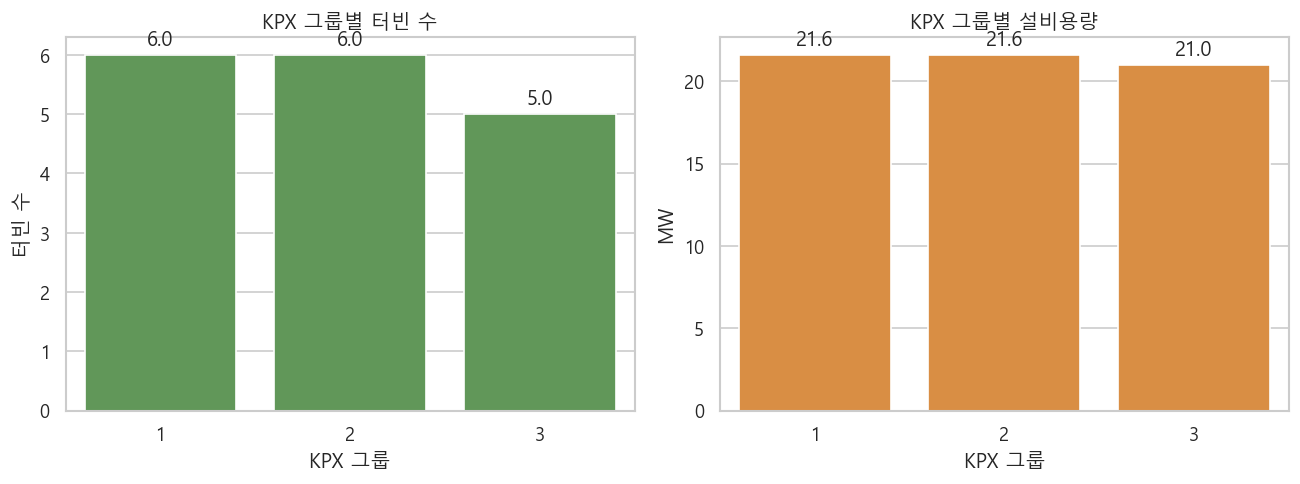

In [14]:
groupInfo = infoTable.groupby("KPX그룹").agg(
  터빈수=("호기", "count"),
  제작사=("제작사", lambda values: ", ".join(sorted(values.unique()))),
  모델명=("모델명", lambda values: ", ".join(sorted(values.unique()))),
  설비용량합_MW=("설비용량(MW)", "sum"),
  그룹설비용량_MW=("그룹설비용량(MW)", "max"),
  허브높이_min=("Hub Height(m)", "min"),
  허브높이_max=("Hub Height(m)", "max"),
  로터직경_min=("Rotor Diameter(m)", "min"),
  로터직경_max=("Rotor Diameter(m)", "max"),
  위도_min=("latitude", "min"),
  위도_max=("latitude", "max"),
  경도_min=("longitude", "min"),
  경도_max=("longitude", "max"),
).reset_index()
groupInfo["용량일치"] = np.isclose(groupInfo["설비용량합_MW"], groupInfo["그룹설비용량_MW"])
display(groupInfo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=groupInfo, x="KPX그룹", y="터빈수", ax=axes[0], color="#59A14F")
axes[0].set_title("KPX 그룹별 터빈 수")
axes[0].set_xlabel("KPX 그룹")
axes[0].set_ylabel("터빈 수")

sns.barplot(data=groupInfo, x="KPX그룹", y="설비용량합_MW", ax=axes[1], color="#F28E2B")
axes[1].set_title("KPX 그룹별 설비용량")
axes[1].set_xlabel("KPX 그룹")
axes[1].set_ylabel("MW")
for ax in axes:
  for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()


### 관찰 -> 해석 -> 다음 판단

**관찰**: Group 1/2는 VESTAS V126 6기씩 21.6MW, Group 3은 UNISON U136 5기 21.0MW로 정리된다.

**해석**: capacity가 target별로 다르므로 kWh raw error만 보면 Group 3이 과소/과대평가될 수 있다. 공식 평가가 capacity-normalized NMAE와 FICR를 쓰는 이유도 설비 규모가 다른 그룹을 공정하게 비교하기 위해서다.

**다음 판단**: 리포트와 validation은 raw kWh, capacity factor, capacity 기반 threshold를 함께 보여준다.


## Decision Box 1: 공식 데이터 감사 후 결정

| 주제 | 결정 | 이유 |
|---|---|---|
| 원본 데이터 stage | 금지 | `data/raw/open/**` 원본 CSV/XLSX는 MANIFEST로만 무결성 추적한다 |
| Group 3 결측 | 2022년 구조적 결측으로 취급 | 0 발전이 아니라 label 미제공 상태이므로 target별 학습 mask가 필요하다 |
| capacity 초과 actual | 원본 수정 금지, 별도 flag 기록 | Group 3 일부 actual이 21,000kWh를 넘으므로 metric/clip 실험에서 해석을 분리한다 |
| weather missing | source별 deterministic imputation 후보 비교 | LDAPS test 결측은 평가 기간 feature 결측이므로 train 통계, 같은 lead/hour, GFS 보완 후보를 비교한다 |
| SCADA 사용 | 학습 보조/EDA 전용 | 평가 기간 SCADA가 없으므로 lag feature 또는 사후 실측 feature 사용은 leakage다 |
| cutoff/leakage | `data_available_kst_dtm` 기준 검증 필요 | forecast target 시각만으로 join하면 실제 이용 가능 시점 이전 정보를 섞을 수 있다 |
| validation | 시간 순서 기반 split 우선 | 풍력/NWP 예보는 계절성·lead bias가 있어 random split보다 temporal holdout이 실전 제출에 가깝다 |
| 제출 재현성 | sample 파일의 id/time 고정 | 제출 생성 시 `forecast_id`, `forecast_kst_dtm`은 변경하지 않고 target만 대체한다 |


## 마무리

이 노트북은 모델 성능을 높이기 위한 노트북이 아니라, 이후 feature engineering과 validation이 지켜야 할 입력 계약을 고정하는 감사 산출물이다.

다음 작업 후보는 baseline RandomForest train/inference 분리이며, 그 전에 이 감사 결과의 Decision Box를 체크리스트로 삼아 cutoff, Group 3 mask, LDAPS test 결측 보정, 제출 template 고정을 코드로 반영해야 한다.
